# 02. CRF NER classifier

Обучение BIO-спанов (`BRAND` / `CATEGORY` / `MODEL` / `ATTR`) на silver из [`01_crf_eda`](./01_crf_eda.ipynb).

| | |
|---|---|
| Silver | `artifacts/silver/ner_bio/silver_bio_slice.parquet` |
| Модель | `models/ner_crf.pkl` |
| Eval | silver-val (optimistic) + **gold** `bio_liza.jsonl` |

Фичи — **не TF-IDF**: shape / аффиксы / соседи (`src/ner/features.py`).

CLI: `python notebooks/crf_ner_classifier/_run_02.py`


## 0. Setup

In [1]:
%matplotlib inline
import sys, json, warnings
from pathlib import Path
from collections import Counter

ROOT = Path.cwd().resolve()
if ROOT.name in {"crf_ner_classifier", "notebooks"}:
    ROOT = ROOT.parents[1] if ROOT.name == "crf_ner_classifier" else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.data_utils import (
    ensure_dirs, apply_plot_style, resolve_silver, MODELS, FIGURES_DIR,
    MVIDEO_RED, DARK_SLATE,
)
from src.ner.labeling import tokenize
from src.ner.metrics import summarize_metrics
from src.ner.model_crf import CRFNerModel

warnings.filterwarnings("ignore", category=FutureWarning)
ensure_dirs()
apply_plot_style()

SEED, VAL_SIZE, MAX_ITERS = 42, 0.2, 80
LABELS = ["BRAND", "CATEGORY", "MODEL", "ATTR"]
FIG = FIGURES_DIR / "ner"
FIG.mkdir(parents=True, exist_ok=True)
GOLD = ROOT / "data" / "gold" / "bio_liza.jsonl"
print("MODELS", MODELS)


d:\Projects-26-06-2026\mvideo-ner-search\.venv\Lib\site-packages\pymorphy2\analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


MODELS D:\Projects-26-06-2026\mvideo-ner-search\models


## 1. Load silver NER BIO

In [2]:
silver_path = resolve_silver("ner_bio", "silver_bio_slice.parquet")
df = pd.read_parquet(silver_path)
print(silver_path, "rows", len(df))
if "has_entity" in df.columns:
    df = df[df["has_entity"]].copy()
print("with_entity", len(df))
display(df[["query", "n_BRAND", "n_CATEGORY", "n_MODEL", "n_ATTR", "bio_str"]].head(8))

bc = Counter()
for tags in df["tags"]:
    for t in tags:
        if str(t).startswith("B-"):
            bc[str(t)[2:]] += 1
print("B-* counts", dict(bc))


D:\Projects-26-06-2026\mvideo-ner-search\artifacts\silver\ner_bio\silver_bio_slice.parquet rows 5000
with_entity 4344


,query,n_BRAND,n_CATEGORY,n_MODEL,n_ATTR,bio_str
0,samsung,1,0,0,0,samsung/B-BRAND
1,накопительные водонагреватели,0,1,0,0,накопительные/B-CATEGORY водонагреватели/I-CAT...
2,мышь,0,1,0,0,мышь/B-CATEGORY
3,пылесос,0,1,0,0,пылесос/B-CATEGORY
4,геймпад xbox,1,1,0,0,геймпад/B-CATEGORY xbox/B-BRAND
5,samsung s25 ultra,1,0,1,0,samsung/B-BRAND s25/B-MODEL ultra/I-MODEL
6,nintendo switch 2,1,0,1,0,nintendo/B-BRAND switch/B-MODEL 2/I-MODEL
7,тихий пылесос,0,1,0,0,тихий/O пылесос/B-CATEGORY


B-* counts {'BRAND': 2446, 'CATEGORY': 3560, 'MODEL': 663, 'ATTR': 782}


## 2. Train / val split + fit CRF

In [3]:
def rows_to_sents(frame):
    out = []
    for _, r in frame.iterrows():
        toks, tags = list(r["tokens"]), list(r["tags"])
        if toks and len(toks) == len(tags):
            out.append(list(zip(toks, tags)))
    return out

train_df, val_df = train_test_split(df, test_size=VAL_SIZE, random_state=SEED)
train_sents, val_sents = rows_to_sents(train_df), rows_to_sents(val_df)
print(f"train={len(train_sents)} val={len(val_sents)}")

model = CRFNerModel(max_iterations=MAX_ITERS)
model.fit(train_sents)
print("fitted")


train=3475 val=869
fitted


## 3. Silver-val metrics (weak↔weak)

In [4]:
y_val = [[t for _, t in s] for s in val_sents]
pred_val = model.predict(val_sents)
silver_m = summarize_metrics(y_val, pred_val)
print(f"tokAcc={silver_m['token_accuracy']:.3f} microF1={silver_m['micro']['f1']:.3f} macro={silver_m['macro_f1']:.3f}")
per = silver_m["per_label"]
display(pd.DataFrame([
    {"label": l, **{k: per[l][k] for k in ("precision","recall","f1","support")}}
    for l in LABELS if l in per
]))


tokAcc=0.864 microF1=0.845 macro=0.811


,label,precision,recall,f1,support
0,BRAND,0.959350,0.963265,0.961303,490
1,CATEGORY,0.796791,0.820937,0.808684,726
2,MODEL,0.755906,0.685714,0.719101,140
3,ATTR,0.869231,0.668639,0.755853,169


## 4. Gold eval (primary)

In [5]:
gold_sents, meta = [], {"n": 0, "tokenize_align": 0, "used": 0, "skipped": 0}
for line in GOLD.read_text(encoding="utf-8").splitlines():
    if not line.strip():
        continue
    r = json.loads(line)
    meta["n"] += 1
    q, tags = r["query"], r["tags"]
    toks = [t for t, _, _ in tokenize(q)]
    if len(toks) == len(tags):
        meta["tokenize_align"] += 1
        gold_sents.append(list(zip(toks, tags)))
        meta["used"] += 1
    elif len(q.split()) == len(tags):
        gold_sents.append(list(zip(q.split(), tags)))
        meta["used"] += 1
    else:
        meta["skipped"] += 1

y_gold = [[t for _, t in s] for s in gold_sents]
pred_gold = model.predict_tokens([[t for t, _ in s] for s in gold_sents])
gold_m = summarize_metrics(y_gold, pred_gold)
print(meta)
print(f"GOLD tokAcc={gold_m['token_accuracy']:.3f} microF1={gold_m['micro']['f1']:.3f} macro={gold_m['macro_f1']:.3f}")
gp = gold_m["per_label"]
display(pd.DataFrame([
    {"label": l, **{k: gp[l][k] for k in ("precision","recall","f1","support")}}
    for l in LABELS if l in gp
]))


{'n': 200, 'tokenize_align': 181, 'used': 200, 'skipped': 0}
GOLD tokAcc=0.582 microF1=0.588 macro=0.512


,label,precision,recall,f1,support
0,BRAND,0.805556,0.820755,0.813084,106
1,CATEGORY,0.622642,0.647059,0.634615,153
2,MODEL,0.518519,0.189189,0.277228,74
3,ATTR,0.703704,0.208791,0.322034,91


## 5. Save + demos + plot

saved D:\Projects-26-06-2026\mvideo-ner-search\models\ner_crf.pkl


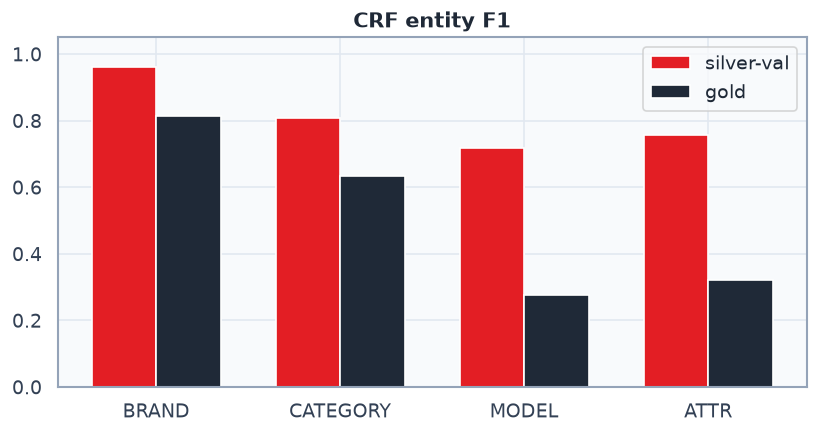

asus tuf gaming a15 16 гб -> asus/B-BRAND tuf/B-MODEL gaming/I-MODEL a15/I-MODEL 16/B-ATTR гб/I-ATTR
ноутбук asus 16 гб -> ноутбук/B-CATEGORY asus/B-BRAND 16/B-ATTR гб/I-ATTR
iphone 15 pro max -> iphone/B-BRAND 15/B-MODEL pro/I-MODEL max/B-BRAND


In [ ]:
model.save(MODELS / "ner_crf.pkl")
model.save(MODELS / "ner_crf__silver_v1.pkl")
print("saved", MODELS / "ner_crf.pkl")

labs = [l for l in LABELS if l in per]
fig, ax = plt.subplots(figsize=(7, 3.8))
x = np.arange(len(labs)); w = 0.35
ax.bar(x - w/2, [per[l]["f1"] for l in labs], w, color=MVIDEO_RED, label="silver-val")
ax.bar(x + w/2, [gp.get(l, {}).get("f1", 0) for l in labs], w, color=DARK_SLATE, label="gold")
ax.set_xticks(x); ax.set_xticklabels(labs); ax.set_ylim(0, 1.05)
ax.set_title("CRF entity F1"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "02_crf_entity_f1.png", dpi=120, bbox_inches="tight"); plt.show()

for q in ["asusu tuf gaming a15 16 гб", "ноутбук asus 16 гб", "iphone 15 pro max"]:
    print(q, "->", " ".join(f"{a}/{b}" for a, b in model.predict_query(q)))


## Verdict

- Silver-val завышен (тот же teacher).
- Смотри **gold micro-F1** в ячейке выше / [`02_crf_report.md`](./02_crf_report.md).
- Дальше: больше silver (`_run_01` ↑ MAX_QUERIES) и правки teacher на MODEL/ATTR misses.
